Training data shape: (1460, 81)
Test data shape: (1459, 80)

Training data description:
                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.63

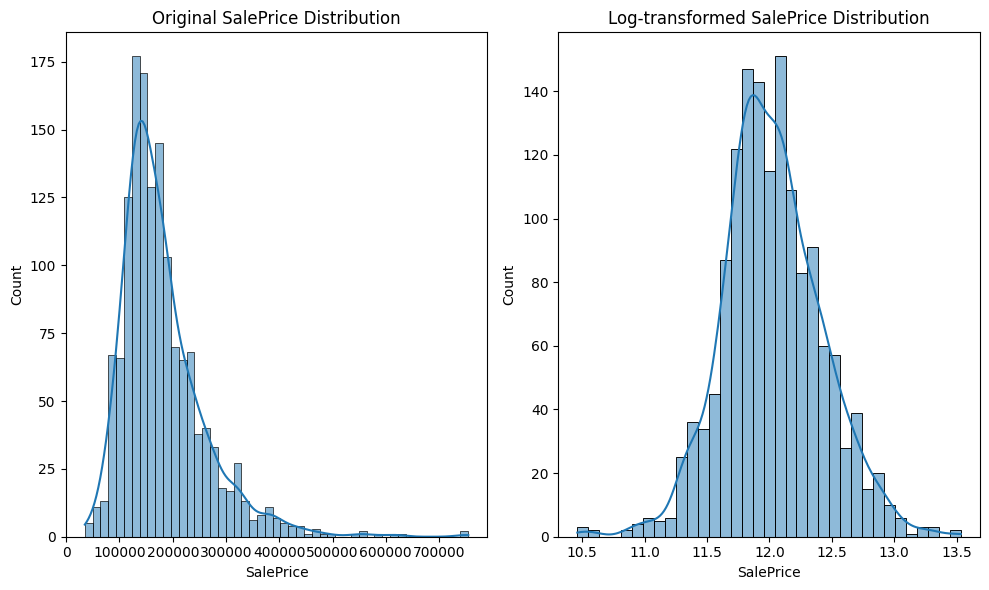

Log-transformed SalePrice skewness: 0.12

Top 10 features correlated with SalePrice:
SalePrice          1.000000
OverallQual        0.817185
TotalUsableArea    0.776418
GrLivArea          0.700927
GarageCars         0.680625
TotalSF            0.634207
TotalBsmtSF        0.612134
1stFlrSF           0.596981
FullBath           0.594771
YearBuilt          0.586570
Name: SalePrice, dtype: float64


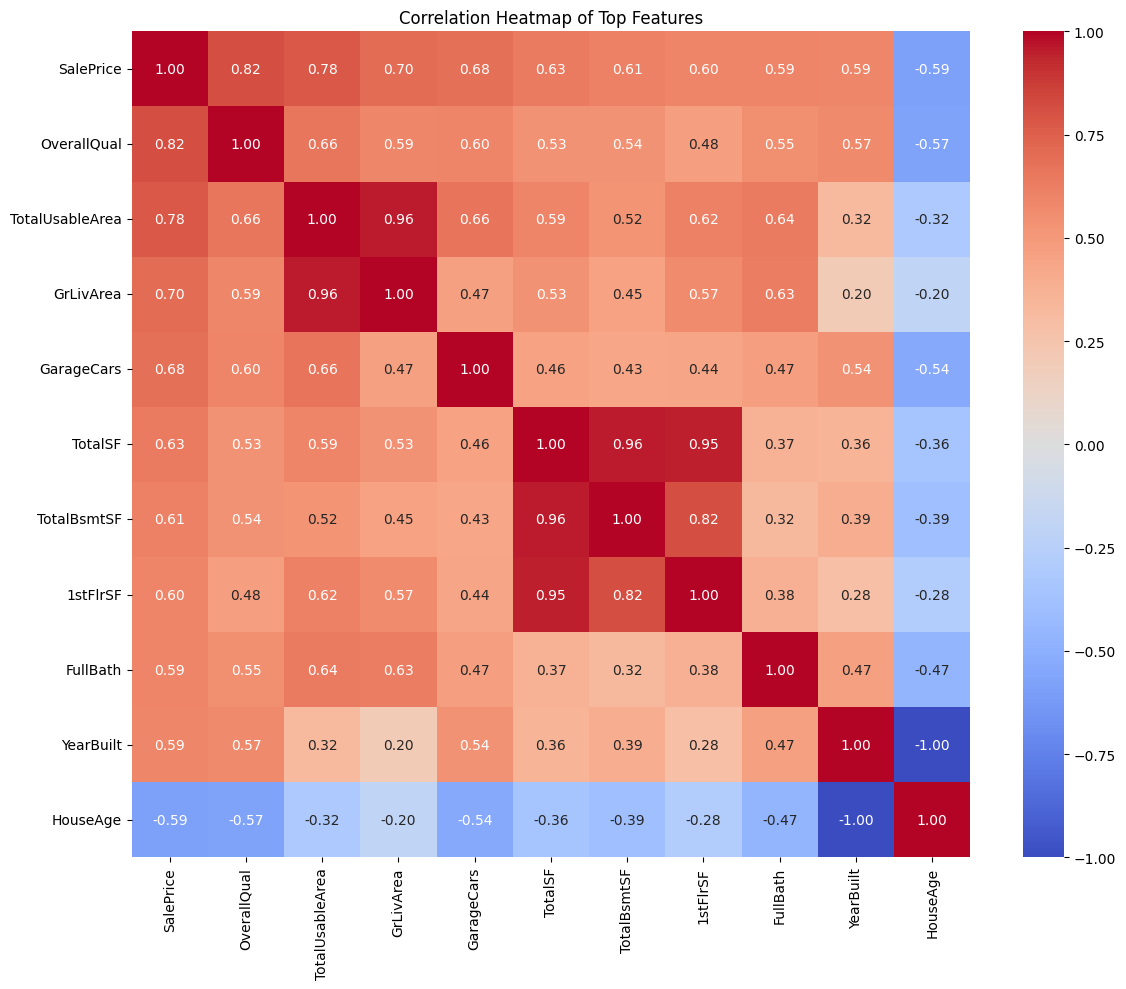

Training set size: (1168, 248)
Validation set size: (292, 248)
Starting grid search...
Fitting 5 folds for each of 48 candidates, totalling 240 fits


In [ ]:
# ----------------------------------------
# 📦 1. Import Required Libraries
# ----------------------------------------
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor  # For feature importance alternative
 
from scipy.stats import skew

# ----------------------------------------
# 📥 2. Load Datasets
# ----------------------------------------
train_df = pd.read_csv("house_prices/train.csv")
test_df = pd.read_csv("house_prices/test.csv")
original_test_df = test_df.copy()

# ----------------------------------------
# 🔎 3. Visualize Raw Data
# ----------------------------------------
# descriptive statistics
print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)
print("\nTraining data description:")
print(train_df.describe())

# ----------------------------------------
# 🧼 4. Data Preprocessing Function
# ----------------------------------------
def preprocess_data(df, is_train=True):
    """
    Preprocess data with consistent transformations for both train and test sets
    """
    df = df.copy()
    
    # Drop columns with too many missing values
    df = df.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence'])
    
    # Fill missing values
    df['MasVnrType'] = df['MasVnrType'].fillna("None")
    
    # Fireplace quality mapping
    fireplace_quality_map = {
        "Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, np.nan: 0
    }
    df['FireplaceQu'] = df['FireplaceQu'].map(fireplace_quality_map)
    
    # Fill numerical missing values
    df['LotFrontage'] = df['LotFrontage'].fillna(df["LotFrontage"].median())
    
    # Fill categorical missing values with "None"
    none_fill_cols = [
        'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
        'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1'
    ]
    for col in none_fill_cols:
        df[col] = df[col].fillna("None")
    
    # Fill numerical missing values with 0
    zero_fill_cols = ['MasVnrArea', 'GarageYrBlt']
    for col in zero_fill_cols:
        df[col] = df[col].fillna(0)
    
    # Fill mode for categorical variables
    if 'Electrical' in df.columns:
        df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
    
    # One-hot encoding (do this BEFORE feature engineering to avoid issues)
    df = pd.get_dummies(df, drop_first=True)
    
    # Feature Engineering (after one-hot encoding)
    df['Remodeled'] = (df['YearRemodAdd'] > df['YearBuilt']).astype(int)
    df['HouseAge'] = 2025 - df['YearBuilt']
    df['RemodAge'] = 2025 - df['YearRemodAdd']
    df['GarageUtil'] = df['GarageArea'] / df['GarageCars'].replace(0, np.nan)
    df['GarageUtil'] = df['GarageUtil'].fillna(0)
    df['TotalUsableArea'] = df['GrLivArea'] + df['GarageArea']
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF']
    df = df.drop(columns=['GarageArea'])
    
    # Log transform target variable (only for training data)
    if is_train and 'SalePrice' in df.columns:
        df['SalePrice'] = np.log1p(df['SalePrice'])
    
    return df

# ----------------------------------------
# 🧼 5. Apply Preprocessing
# ----------------------------------------
print("Preprocessing training data...")
train_processed = preprocess_data(train_df, is_train=True)

print("Preprocessing test data...")
test_processed = preprocess_data(test_df, is_train=False)

# ----------------------------------------
# 🔄 6. Align Columns Between Train and Test
# ----------------------------------------
# Get common columns (excluding SalePrice)
train_features = [col for col in train_processed.columns if col != 'SalePrice']
test_features = list(test_processed.columns)

# Find missing columns in test data
missing_in_test = set(train_features) - set(test_features)
missing_in_train = set(test_features) - set(train_features)

print(f"Columns in train but not in test: {len(missing_in_test)}")
print(f"Columns in test but not in train: {len(missing_in_train)}")

# Add missing columns to test data (fill with 0)
for col in missing_in_test:
    test_processed[col] = 0

# Add missing columns to train data (fill with 0)
for col in missing_in_train:
    train_processed[col] = 0

# Reorder columns to match
common_features = sorted(set(train_features) | set(test_features))
train_processed = train_processed[common_features + ['SalePrice']]
test_processed = test_processed[common_features]

print(f"Final feature count: {len(common_features)}")

# ----------------------------------------
# 📊 7. Exploratory Data Analysis (EDA)
# ----------------------------------------
# Plot distribution of log-transformed SalePrice
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
sns.histplot(train_df['SalePrice'], kde=True)
plt.title("Original SalePrice Distribution")

plt.subplot(1, 2, 2)
sns.histplot(train_processed['SalePrice'], kde=True)
plt.title("Log-transformed SalePrice Distribution")
plt.tight_layout()
plt.show()

# Measure skewness
saleprice_skew = skew(train_processed['SalePrice'])
print(f"Log-transformed SalePrice skewness: {saleprice_skew:.2f}")

# Correlation analysis
numeric_cols = train_processed.select_dtypes(include=[np.number]).columns
corr_matrix = train_processed[numeric_cols].corr()
saleprice_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False)

print("\nTop 10 features correlated with SalePrice:")
print(saleprice_corr.head(10))

# Plot heatmap for top correlated features
top_corr_features = saleprice_corr.head(11).index
plt.figure(figsize=(12, 10))
sns.heatmap(train_processed[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Top Features")
plt.tight_layout()
plt.show()

# ----------------------------------------
# 🤖 8. Model Training and Validation
# ----------------------------------------
# Prepare data
X = train_processed.drop(columns=['SalePrice'])
y = train_processed['SalePrice']

# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

# Grid search parameters
param_grid = {
    'svr__kernel': ['rbf', 'linear'],
    'svr__C': [0.1, 1, 10, 100],
    'svr__epsilon': [0.01, 0.1, 0.5],
    'svr__gamma': ['scale', 'auto']
}

# Perform grid search
print("Starting grid search...")
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    refit=True,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation RMSE:", -grid_search.best_score_)

# ----------------------------------------
# 📈 9. Model Evaluation
# ----------------------------------------
# Make predictions on validation set
y_pred = grid_search.predict(X_val)

# Calculate metrics
rmse = mean_squared_error(y_val, y_pred, squared=False)
r2 = r2_score(y_val, y_pred)

print(f"\nValidation RMSE: {rmse:.4f}")
print(f"Validation R² Score: {r2:.4f}")

# Plot predicted vs actual
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, alpha=0.6)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], '--r', lw=2)
plt.xlabel("Actual SalePrice (log)")
plt.ylabel("Predicted SalePrice (log)")
plt.title("SVR: Predicted vs Actual")
plt.tight_layout()
plt.show()

# Plot residuals
residuals = y_val - y_pred
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='purple')
plt.title("Residuals Distribution")
plt.xlabel("Residual")

plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted SalePrice (log)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.tight_layout()
plt.show()

# Cross-validation scores
cv_rmse = cross_val_score(grid_search.best_estimator_, X, y,
                          scoring='neg_root_mean_squared_error', cv=5)
cv_rmse = -cv_rmse

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_rmse, color='teal')
plt.title("Cross-Validation RMSE per Fold")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.xticks(range(1, 6))
plt.tight_layout()
plt.show()

print(f"\nMean CV RMSE: {cv_rmse.mean():.4f}")
print(f"Standard Deviation: {cv_rmse.std():.4f}")

# ----------------------------------------
# 📤 10. Create Submission File
# ----------------------------------------
print("Making predictions on test set...")
test_predictions = grid_search.predict(test_processed)

# Create submission dataframe
submission = pd.DataFrame({
    'Id': original_test_df['Id'],
    'SalePrice': np.expm1(test_predictions)  # Undo log1p transformation
})

# Save submission
submission.to_csv("house_prices_submission.csv", index=False)
print("Submission file saved as 'house_prices_submission.csv'")
print(f"Submission shape: {submission.shape}")
print(f"Price range: ${submission['SalePrice'].min():.0f} - ${submission['SalePrice'].max():.0f}")

# ----------------------------------------
# 🎯 11. Feature Importance Analysis (Alternative Method)
# ----------------------------------------
print("\nSince SVR doesn't have feature_importances_, training Random Forest for feature importance analysis...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importances
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
top_features = feature_importance_df.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance_df.head(10))

# Compare Random Forest vs SVR performance
rf_pred = rf_model.predict(X_val)
# Compute RMSE manually
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
rf_r2 = r2_score(y_val, rf_pred)

print(f"\nModel Comparison:")
print(f"SVR - RMSE: {rmse:.4f}, R²: {r2:.4f}")
print(f"Random Forest - RMSE: {rf_rmse:.4f}, R²: {rf_r2:.4f}")

# Note: SVR is the main model used for final predictions

# ----------------------------------------
# 💾 12. Save Model
# ----------------------------------------
print("\nSaving trained model...")
joblib.dump(grid_search.best_estimator_, 'house_price_model.pkl')
print("Model saved as 'house_price_model.pkl'")

print("\n✅ Analysis complete!")